In [1]:
#%%
%load_ext autoreload
%autoreload 2

#### How much do the sets of individuals that models predict as 0 overlap?

In [2]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
from itertools import accumulate
import scipy as sp
from pathlib import Path
import logging
logging.getLogger().setLevel(logging.INFO)

#load the dataset
import folktexts
from folktexts.acs.acs_tasks import ACSTaskMetadata
from folktexts.acs.acs_dataset import ACSDataset
from folktexts.llm_utils import get_model_size_B

from monoculture.analysis.setup import ACS_TASKS, TABLESHIFT_TASKS, baselines
from monoculture.analysis.metrics import poisson_binom_agreement
from monoculture.analysis.utils import key_to_model, get_metric, get_predictions, prettify_model_name, is_instruction_tuned, truncate
from monoculture.baseline.utils import load_baselines

plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

RESULTS_ROOT_DIR = Path("./results/")
results_df_path = RESULTS_ROOT_DIR/'overview_results_by_prompt_style.csv'

TASKS = ACS_TASKS + TABLESHIFT_TASKS

INFO:datasets:PyTorch version 2.5.1 available.


#### Load Dataframe

In [3]:
df = pd.read_csv(results_df_path)
# restrict to zero-shot and same prompt style
prompt_style = "bullet"
prompt_connector = "is"  #':','=', 'is'
df = df[
    (df["num_shots"] == 0)
    & (df["prompt_style"] == "bullet")
    & (df["prompt_connector"] == "is")
    & (df["threshold_fitted"] == 1)
]
print(df.shape)
df.sample(n=10)

(288, 10)


,task,model,is_inst,threshold_fitted,bench_hash,num_shots,prompt_style,prompt_connector,eval_results_path,predictions_path
205,ACSEmployment,meta-llama--Meta-Llama-3.2-3B,0,1,4031989289,0,bullet,is,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...
523,ACSPublicCoverage,meta-llama--Meta-Llama-3.1-8B,0,1,1702665013,0,bullet,is,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...
451,ACSTravelTime,allenai--OLMo-1B-0724-hf,0,1,2712026168,0,bullet,is,results/folktexts/0-bullet-is/model-allenai--O...,results/folktexts/0-bullet-is/model-allenai--O...
819,BRFSS_Blood_Pressure,01-ai--Yi-6B-Chat,1,1,1339001661,0,bullet,is,results/tableshift/0-bullet-is/model-01-ai--Yi...,results/tableshift/0-bullet-is/model-01-ai--Yi...
221,ACSEmployment,meta-llama--Meta-Llama-3.1-70B,0,1,470895502,0,bullet,is,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...
702,BRFSS_Diabetes,01-ai--Yi-6B-Chat,1,1,4285716299,0,bullet,is,results/tableshift/0-bullet-is/model-01-ai--Yi...,results/tableshift/0-bullet-is/model-01-ai--Yi...
713,BRFSS_Diabetes,mistralai--Mixtral-8x7B-Instruct-v0.1,1,1,3029206557,0,bullet,is,results/tableshift/0-bullet-is/model-mistralai...,results/tableshift/0-bullet-is/model-mistralai...
358,ACSTravelTime,meta-llama--Meta-Llama-3.2-1B-Instruct,1,1,2315633811,0,bullet,is,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...
693,BRFSS_Diabetes,mistralai--Mixtral-8x7B-v0.1,0,1,2300995655,0,bullet,is,results/tableshift/0-bullet-is/model-mistralai...,results/tableshift/0-bullet-is/model-mistralai...
666,BRFSS_Diabetes,allenai--OLMo-2-1124-7B,0,1,2326960478,0,bullet,is,results/tableshift/0-bullet-is/model-allenai--...,results/tableshift/0-bullet-is/model-allenai--...


In [4]:
baseline_scores, baseline_evals = load_baselines(baselines=baselines, tasks=TASKS)

Loading baselines for ACSIncome.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSIncome'.
- LR: Load predictions from 'results/baselines/LR_task-ACSIncome'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSIncome'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSIncome'.
Loading baselines for ACSEmployment.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSEmployment'.
- LR: Load predictions from 'results/baselines/LR_task-ACSEmployment'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSEmployment'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSEmployment'.
Loading baselines for ACSTravelTime.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSTravelTime'.
- LR: Load predictions from 'results/baselines/LR_task-ACSTravelTime'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSTravelTime'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-A

In [5]:
baseline_predictions = {task:baseline_scores[task].map(lambda x: int(x >= 0.5)) for task in TASKS}
baseline_predictions['ACSIncome'].head()    

,Constant_task-ACSIncome,LR_task-ACSIncome,GBM_task-ACSIncome,XGBoost_task-ACSIncome
238351,0,0,0,0
2995677,0,0,0,0
2360043,0,0,1,1
1924596,0,0,0,0
2803585,0,0,0,0


In [6]:
# load predictions and measured accuracies
predictions = {}
accuracies = {}
fn_rates = {}
for task in TASKS:
    task_df = df[(df["task"] == task)]

    # available models
    models = task_df["model"].unique().tolist()
    models.sort(key=lambda m: get_model_size_B(m) + int(is_instruction_tuned(m)))
    predictions_per_task = []
    accuracies[task] = {}
    fn_rates[task] = {}
    for m in models:
        data_m = task_df[task_df["model"] == m]
        assert (
            data_m.shape[0] == 1
        ), f"Expected 1 row for model {m} but found {data_m.shape[0]}"
        accuracies[task][m] = get_metric(
            data_m.iloc[0]["eval_results_path"], metric="accuracy"
        )
        fn_rates[task][m] = get_metric(
            data_m.iloc[0]["eval_results_path"], metric="fnr"
        )
        predictions_per_task.append(
            get_predictions(
                data_m.iloc[0]["predictions_path"],
                eval_json_path=data_m.iloc[0]["eval_results_path"],
            )
        )
    predictions[task] = pd.concat(predictions_per_task, axis=1)

In [7]:
models_above_baseline = {}
baselines_above_baseline = {}
for task in TASKS:
    baseline_acc = baseline_evals[task]['Constant']['accuracy'] 
    models_above_baseline[task] = [model for model in predictions[task].keys().tolist() if truncate(accuracies[task][model], 6) > truncate(baseline_acc, 6)]
    #baselines_above_baseline[task] = [baseline for baseline in list(baselines.keys()) if baseline_evals[task][baseline]['accuracy']  > baseline_acc]
    num_models = len(models_above_baseline[task])
    print(task, num_models) #, models_above_baseline[task])

ACSIncome 40
ACSEmployment 42
ACSTravelTime 19
ACSPublicCoverage 12
BRFSS_Diabetes 0
BRFSS_Blood_Pressure 36


In [8]:
# check for constant predictors
for task in TASKS: # TASKS:
    num_individuals = predictions[task].shape[0]
    num_accepted = predictions[task].sum(axis=0) # only above baseline: predictions[task][models_above_baseline[task]]
    num_rejected = num_individuals - num_accepted
    dict_num_accepted = num_accepted.to_dict()
    dict_num_rejected = num_rejected.to_dict()
    const_1 = [m for m in predictions[task].keys().tolist() if num_accepted[m] == num_individuals] # models_above_baseline[task]
    const_0 = [m for m in predictions[task].keys().tolist() if num_rejected[m] == num_individuals] # models_above_baseline[task] 
    print(f"{task} (n={num_individuals})\n- const 1: {const_1 if len(const_1) > 0 else '-'}\n- const 0: {const_0 if len(const_0) > 0 else '-'}")

ACSIncome (n=166450)
- const 1: -
- const 0: -
ACSEmployment (n=323611)
- const 1: -
- const 0: -
ACSTravelTime (n=146665)
- const 1: -
- const 0: -
ACSPublicCoverage (n=113829)
- const 1: -
- const 0: ['meta-llama--Meta-Llama-3.2-1B-Instruct']
BRFSS_Diabetes (n=144418)
- const 1: -
- const 0: -
BRFSS_Blood_Pressure (n=84676)
- const 1: -
- const 0: -


In [9]:
# check for constant predictors amon models better than baseline
for task in ACS_TASKS:
    num_individuals = predictions[task].shape[0]
    num_accepted = predictions[task][models_above_baseline[task]].sum(axis=0) 
    num_rejected = num_individuals - num_accepted
    prob_rejected = (num_individuals - num_accepted) / num_individuals
    dict_num_accepted = num_accepted.to_dict()
    dict_num_rejected = num_rejected.to_dict()
    dict_prob_rejected = prob_rejected.to_dict()
    const_1 = [m for m in models_above_baseline[task] if num_accepted[m] == num_individuals] # models_above_baseline[task]
    const_0 = [m for m in models_above_baseline[task] if num_rejected[m] == num_individuals] # models_above_baseline[task] 
    print(f"{task} (n={num_individuals})\n- const 1: {const_1 if len(const_1) > 0 else '-'}\n- const 0: {const_0 if len(const_0) > 0 else '-'}")
    print("Probability of rejections by models above baseline")
    print('\n'.join([f'- {prettify_model_name(key_to_model(key)): <30} {val:.6f} \taccepted: {dict_num_accepted[key]}' for (key, val) in dict_prob_rejected.items()]))
    print()


ACSIncome (n=166450)
- const 1: -
- const 0: -
Probability of rejections by models above baseline
- Llama 3.2 1B (it)              0.545443 	accepted: 75661
- Llama 3.2 3B                   0.601105 	accepted: 66396
- Llama 3.2 3B (it)              0.457957 	accepted: 90223
- Yi 6B                          0.597116 	accepted: 67060
- OLMo 2 7B                      0.513476 	accepted: 80982
- Mistral 7B                     0.512244 	accepted: 81187
- Qwen 2 7B                      0.455278 	accepted: 90669
- Yi 6B (chat)                   0.485659 	accepted: 85612
- Qwen 2.5 7B                    0.513752 	accepted: 80936
- Gemma 7B                       0.674827 	accepted: 54125
- OLMo 2 7B (it)                 0.483653 	accepted: 85946
- Llama 3 8B                     0.661610 	accepted: 56325
- Llama 3.1 8B                   0.498047 	accepted: 83550
- Qwen 2.5 7B (it)               0.562115 	accepted: 72886
- Qwen 2 7B (it)                 0.546885 	accepted: 75421
- Mistral 7B (it)

#### Load data

In [ ]:
# Fetch task and dataset
from monoculture.analysis.utils import load_task_data
data = load_task_data(TASKS, Path("./data"))

INFO:root:Changing Q&A mode for task 'ACSIncome' to multiple-choice.
INFO:root:Loading ACS data...
INFO:root:Changing Q&A mode for task 'ACSEmployment' to multiple-choice.
INFO:root:Loading ACS data...
INFO:root:Changing Q&A mode for task 'ACSTravelTime' to multiple-choice.
INFO:root:Loading ACS data...
INFO:root:Changing Q&A mode for task 'ACSPublicCoverage' to multiple-choice.
INFO:root:Loading ACS data...


## Plotting

In [13]:
predictions_above_baseline = {key:val.filter(items=models_above_baseline[key]) for key,val in predictions.items() if key in ACS_TASKS}

In [14]:
from monoculture.analysis.plotting import get_observed_rejections

#### Histogram: Fraction by number of models rejecting

INFO:root:M too large, Estimate expectation by sampling fixed number of permutations.


ACSIncome


NotImplementedError: Simulated expectation is not yet implemented

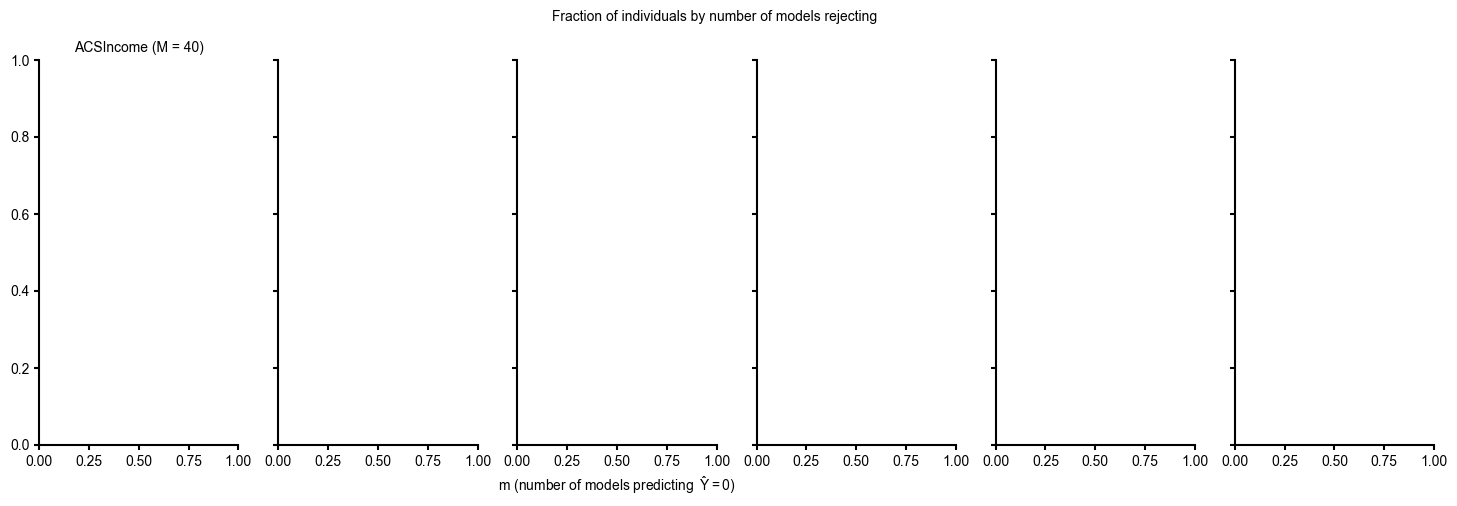

In [17]:
# Fraction of individuals by number of models rejecting
fig, axs = plt.subplots(1,len(tasks), figsize=(18,5), sharey=True)
fig.suptitle('Fraction of individuals by number of models rejecting')
axs[2].set_xlabel("$m$ (number of models predicting $\hat{\,Y}=0$)")

for i, task in enumerate(tasks):
    print(task)
    logging.debug('Ensure only models above baseline are loaded! Currently not available for tableshift tasks')
    M = len(models_above_baseline[task]) if task in ACS_TASKS else len(predictions[task].columns)
    axs[i].set_title(f"{task} (M = {M})")

    # observed 
    values_all, counts_all = get_observed_rejections(predictions=predictions_above_baseline[task] if task in ACS_TASKS else predictions[task], restrict_only_pos_instances=False, true_labels=data[task][1])
    values_neg, counts_neg = get_observed_rejections(predictions=predictions_above_baseline[task] if task in ACS_TASKS else predictions[task], restrict_only_pos_instances=False, restrict_only_neg_instances=True, true_labels=data[task][1])
    num_samples = sum(counts_all)
        
    # expected
    #prob_random = np.array([sp.special.binom(num_models, i) * 2**(-num_models) for i in range(0,num_models+1)])
    if task in ACS_TASKS:
        fn_rates_filtered = [fn_rates[task][model] for model in models_above_baseline[task]]
    else:
        fn_rates_filtered = [fn_rates[task][model] for model in predictions[task].columns]

    prob_expected = np.array([poisson_binom_agreement(fn_rates=fn_rates_filtered, k=i) for i in range(0,M+1)])

    width=0.25
    axs[i].set_xticks(np.arange(M+1)+width, np.arange(M+1))
    axs[i].bar(np.arange(M+1), prob_expected, width=width, color='orange', label='random error')
    axs[i].bar(values_all+width, counts_all/num_samples, width=width, color='C0', label='$P(\hat{\,Y}=0)$')
    axs[i].bar(values_neg+2*width, counts_neg/num_samples, width=width, color='C2', label='$P(\hat{\,Y}=0|Y=0)$')
    

    if i==0:
        axs[i].legend()
# plt.savefig(RESULTS_ROOT_DIR/'figures/same_prompt_individual_all_rejections.png')
plt.show()

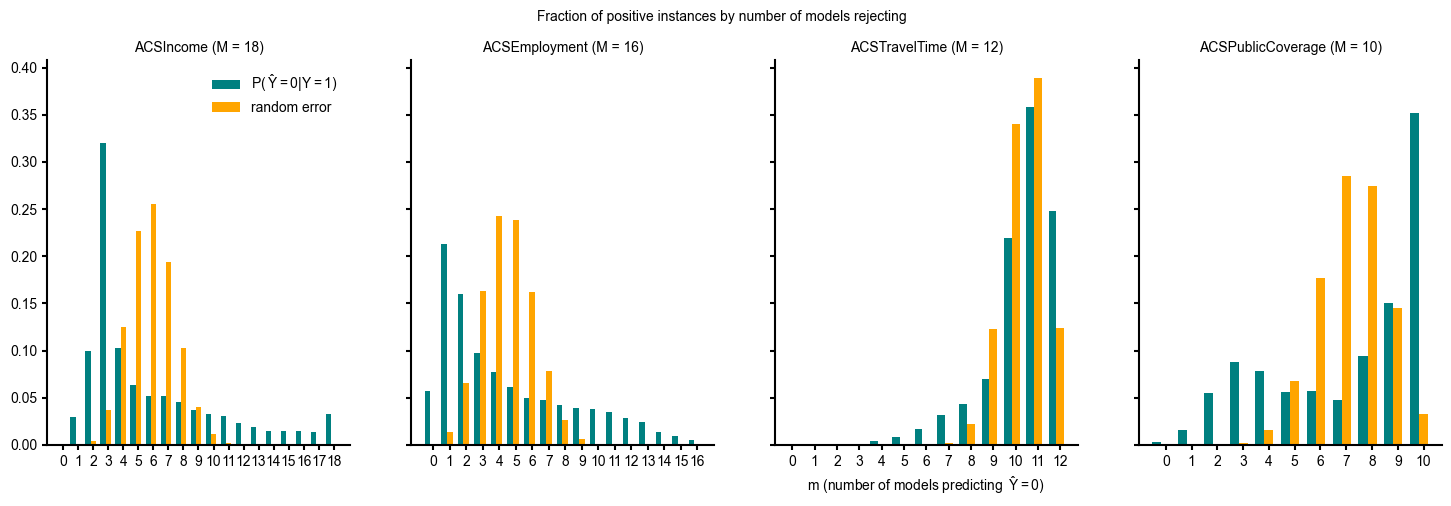

In [15]:
# Fraction of positive instances by number of models rejecting
fig, axs = plt.subplots(1,len(tasks), figsize=(18,5), sharey=True)
fig.suptitle('Fraction of positive instances by number of models rejecting')
axs[2].set_xlabel("$m$ (number of models predicting $\hat{\,Y}=0$)")

for i, task in enumerate(tasks):
    M = len(models_above_baseline[task])
    axs[i].set_title(f"{task} (M = {M})")

    # observed 
    values, counts = get_observed_rejections(predictions=predictions_above_baseline[task], restrict_only_pos_instances=True, true_labels=data[task][1])
    num_samples = sum(counts)
        
    # expected
    #prob_random = np.array([sp.special.binom(num_models, i) * 2**(-num_models) for i in range(0,num_models+1)])
    fn_rates_filtered = [fn_rates[task][model] for model in models_above_baseline[task]]
    prob_expected = np.array([poisson_binom_agreement(fn_rates=fn_rates_filtered, k=i) for i in range(0,M+1)])

    width=0.35
    axs[i].set_xticks(np.arange(M+1)+width, np.arange(M+1))
    axs[i].bar(values, counts/num_samples, width=width, color='teal', label='$P(\hat{\,Y}=0|Y=1)$')
    axs[i].bar(np.arange(M+1)+width, prob_expected, width=width, color='orange', label='random error')

    if i==0:
        axs[i].legend()
plt.savefig(RESULTS_ROOT_DIR/'figures/same_prompt_individual_positives_rejections.png')
plt.show()

INFO:root:M too large, Estimate expectation by sampling fixed number of permutations.


ACSIncome
tensor([16857, 10193,  5425,  3310,  2201,  1739,  1387,  1148,   984,   813,
          705,   592,   601,   610,   542,   534,   466,   438,   436,   433,
          408,   442,   453,   424,   436,   411,   409,   435,   423,   424,
          441,   422,   425,   493,   502,   530,   620,   710,   819,  1211,
         1381])


NotImplementedError: Simulated expectation is not yet implemented

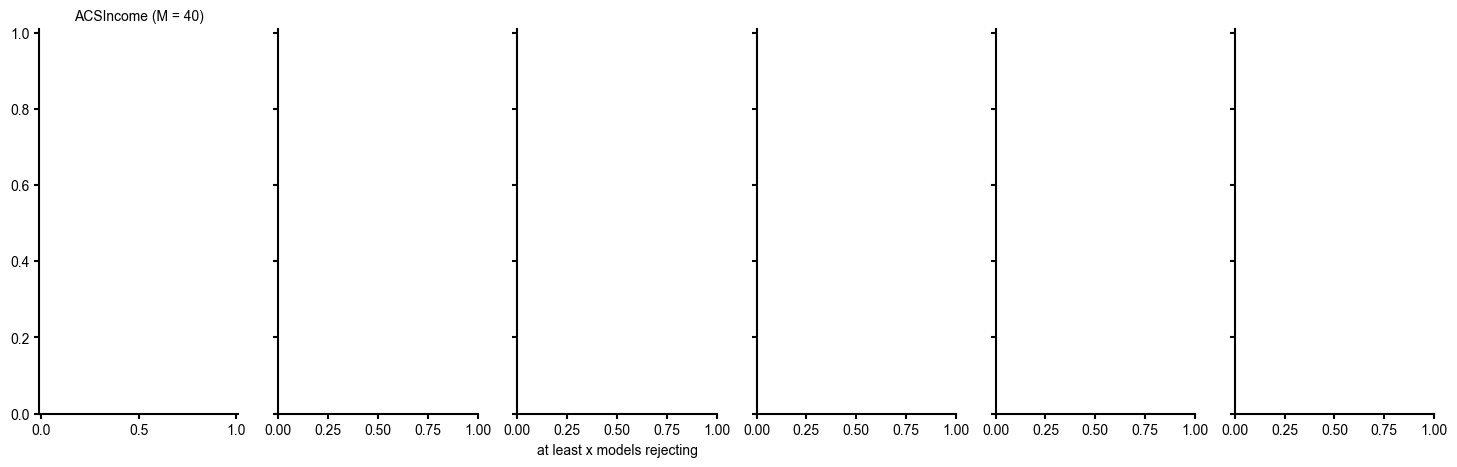

In [16]:
# Fraction of positive instances by number of models rejecting
fig, axs = plt.subplots(1,len(tasks), figsize=(18,5), sharey=True)
# fig.suptitle('Fraction of positive instances rejected')
axs[2].set_xlabel("at least x models rejecting")

for i, task in enumerate(tasks):
    print(task)
    M = len(models_above_baseline[task])
    axs[i].set_title(f"{task} (M = {M})")
    axs[i].set_xlim(-0.01,1.01)
    axs[i].set_ylim(0.0,1.01)

    # observed 
    values, counts = get_observed_rejections(predictions=predictions_above_baseline[task], restrict_only_pos_instances=True, true_labels=data[task][1])
    # pad counts with zeros to ensure correct slicing for recourse
    values_list = list(values)
    counts_padded = torch.tensor([counts[values_list.index(num)] if num in values_list else torch.tensor(0) for num in torch.arange(M+1)])
    print(counts_padded)
    num_samples = sum(counts)
        
    # expected
    #prob_random = np.array([sp.special.binom(num_models, i) * 2**(-num_models) for i in range(0,num_models+1)])
    fn_rates_filtered = [fn_rates[task][model] for model in models_above_baseline[task]]
    prob_expected = np.array([poisson_binom_agreement(fn_rates=fn_rates_filtered, k=i) for i in range(0,M+1)])

    width=0.02
    accumulated = lambda tens: [tens[i:].sum() for i in range(len(tens))]
    axs[i].bar(values/M, counts/num_samples, width=width, color='C0')
    axs[i].plot(torch.arange(M+1)/M,accumulated(counts_padded/num_samples), color='C0', label='observed')
    axs[i].bar(torch.arange(M+1)/M+width, prob_expected, width=width, color='C1')
    # axs[i].bar(torch.arange(M+1)/M+0.025, prob_expected, width=0.05, color='C1')
    axs[i].plot(torch.arange(M+1)/M,accumulated(prob_expected), color='C1', label='random error')
    # axs[i].bar(values, counts/num_samples, width=width, color='teal', label='$P(\hat{\,Y}=0|Y=1)$')
    # axs[i].bar(np.arange(M+1)+width, prob_expected, width=width, color='orange', label='random error')

    if i==0:
        axs[i].legend()
        axs[0].set_ylabel('fraction rejected')
# plt.savefig(RESULTS_ROOT_DIR/'figures/same_prompt_individual_positives_rejections.png')
plt.show()

In [53]:
values, counts/num_samples

(tensor([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14.,
         15., 16., 17., 18.]),
 tensor([0.0538, 0.1805, 0.5778, 0.1846, 0.1144, 0.0932, 0.0945, 0.0819, 0.0674,
         0.0597, 0.0560, 0.0419, 0.0338, 0.0273, 0.0258, 0.0264, 0.0251, 0.0583]))

In [47]:
from itertools import accumulate
torch.Tensor(list(accumulate(counts/num_samples)))

tensor([0.0031, 0.0193, 0.0749, 0.1629, 0.2414, 0.2977, 0.3553, 0.4035, 0.4983,
        0.6484, 1.0000])

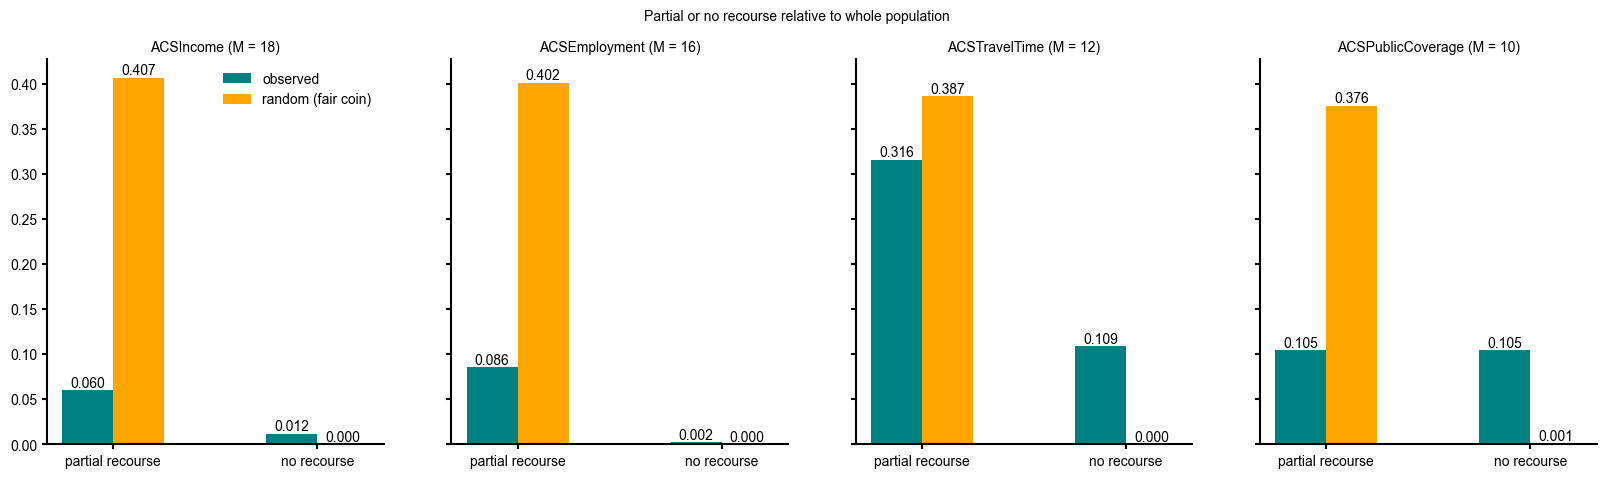

In [16]:
fig, axs = plt.subplots(1,len(tasks), figsize=(20,5), sharey=True); fig.suptitle('Partial or no recourse relative to whole population')

for i, task in enumerate(tasks):
    num_models = len(models_above_baseline[task])
    axs[i].set_title(f"{task} (M = {num_models})")

    num_models_rejected = num_models - predictions_above_baseline[task].sum(axis=1) #series: count of rejecting models
    
    y_test = data[task][1]
    indices_pos = y_test[y_test==1].index
    num_models_rejected_neg = num_models_rejected.loc[indices_pos] #filter: only positive instances
        
    prob_random = np.array([sp.special.binom(num_models, i) * 2**(-num_models) for i in range(0,num_models+1)])
    counts_rejected = np.array([len(num_models_rejected[num_models_rejected==i]) for i in range(0,num_models+1)])
    counts_rejects_neg = np.array([len(num_models_rejected_neg[num_models_rejected_neg==i]) for i in range(0,num_models+1)])

    partial_recourse = counts_rejects_neg[num_models//2+1:-1].sum()/y_test.shape[0]
    no_recourse = counts_rejects_neg[-1]/y_test.shape[0]

    width=0.25
    axs[i].set_xticks(np.arange(2)+0.5*width, [f'partial recourse', f'no recourse'])
    obs_bar = axs[i].bar(np.arange(2), [partial_recourse, no_recourse], width=width, color='teal', label='observed')
    rnd_bar = axs[i].bar(np.arange(2)+width, [prob_random[num_models//2+1:-1].sum(), prob_random[-1]], width=width, color='orange', label='random (fair coin)')
    axs[i].bar_label(obs_bar, fmt='%.3f', label_type='edge')
    axs[i].bar_label(rnd_bar, fmt='%.3f', label_type='edge')

    if i==0:
        axs[i].legend()

plt.savefig(RESULTS_ROOT_DIR/'figures/same_prompt_individual_recourse_to_whole_population.png')
plt.show()

### Recourse

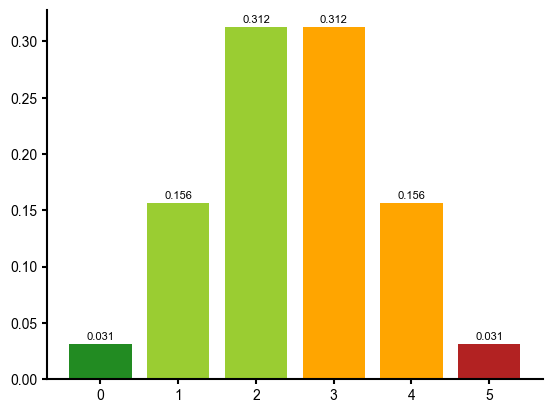

In [15]:
def minimal_example_binomial(color_by_recourse=False):
    num = 5
    cut_off = (num+1)//2
    if color_by_recourse:
        colors = ['forestgreen'] + (cut_off-1)*['yellowgreen'] + (cut_off-1)*['orange'] + ['firebrick']
    else:
        colors = 'C0'
    probs = np.array([sp.special.binom(num, i) * 2**(-num) for i in range(0,num+1)])
    fig, ax = plt.subplots()
    bars = ax.bar(np.arange(num+1), probs, color=colors)
    ax.bar_label(bars, fmt='%.3f', label_type='edge', size=8, padding=2)
    ax.set_xticks(np.arange(num+1))
    # if color_by_recourse:
    #         # Create a Rectangle patch
    #         rect = patches.Rectangle((-0.5, -0.3), 1, 0.6, linewidth=1, edgecolor=colors[0], facecolor='none', zorder=5)
    #         # Add the patch to the Axes
    #         ax.add_patch(rect)
    plt.savefig(RESULTS_ROOT_DIR/'figures/same_prompt_individual_recourse_minimal_example.png')
    plt.show()
    probs[0], probs[:cut_off].sum(), probs[cut_off:-1].sum(), probs[-1]

    
minimal_example_binomial(color_by_recourse=True)

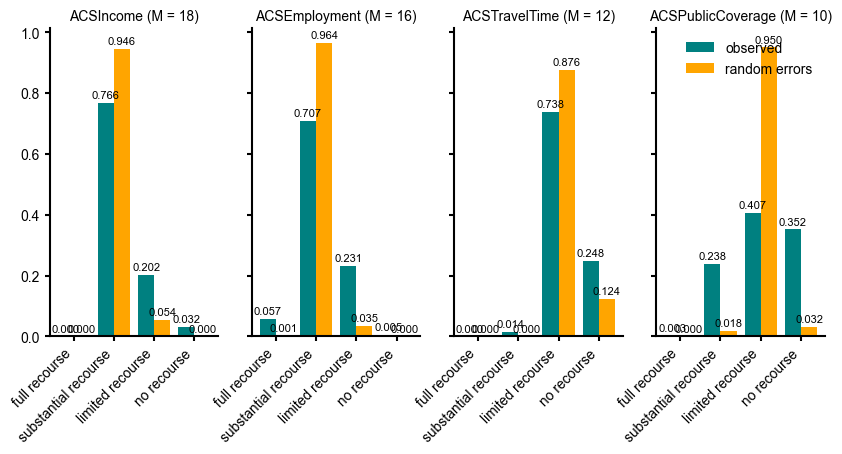

In [18]:
# Recourse among positive instances
fig, axs = plt.subplots(1,len(tasks), figsize=(10,4), sharey=True)
# fig.suptitle('Recourse among positive instances')

for i, task in enumerate(tasks):
    M = len(models_above_baseline[task])
    axs[i].set_title(f"{task} (M = {M})")

    # observed 
    values, counts = get_observed_rejections(predictions=predictions_above_baseline[task], restrict_only_pos_instances=True, true_labels=data[task][1])
    # pad counts with zeros to ensure correct slicing for recourse
    values_list = list(values)
    counts_padded = torch.tensor([counts[values_list.index(num)] if num in values_list else torch.tensor(0) for num in torch.arange(M+1)])
    num_samples = sum(counts)
        
    # expected
    #prob_random = np.array([sp.special.binom(num_models, i) * 2**(-num_models) for i in range(0,num_models+1)])
    fn_rates_filtered = [fn_rates[task][model] for model in models_above_baseline[task]]
    prob_expected = np.array([poisson_binom_agreement(fn_rates=fn_rates_filtered, k=i) for i in range(0,M+1)])

    # recourse
    cut_off = (M+1)//2
    recourse = {'full': slice(1), 'substantial': slice(1,cut_off), 'limited': slice(cut_off, M), 'no': slice(M, M+1)}

    width=0.4
    axs[i].set_xticks(np.arange(4)+0.5*width, [f'full recourse',f'substantial recourse', f'limited recourse', f'no recourse'], rotation=45, ha='right')
    obs_bar = axs[i].bar(np.arange(4), [counts_padded[s].sum()/num_samples for _,s in recourse.items()], width=width, color='teal', label='observed')
    rnd_bar = axs[i].bar(np.arange(4)+width, [prob_expected[s].sum() for _,s in recourse.items()], width=width, color='orange', label='random errors')
    axs[i].bar_label(obs_bar, fmt='%.3f', label_type='edge', size=8, padding=2)
    axs[i].bar_label(rnd_bar, fmt='%.3f', label_type='edge', size=8, padding=2)

    if i==len(tasks)-1:
        axs[i].legend()

plt.savefig(RESULTS_ROOT_DIR/'figures/same_prompt_individual_recourse.png')
plt.show()



### Recourse By Model Family

In [19]:
model_families = ['gemma', 'llama', 'mistral', 'OLMo', 'Qwen', 'Yi']

ACSIncome
Gemma 2 9B (it)

ACSEmployment
Gemma 7B (it), Gemma 2 9B (it)

ACSTravelTime
Gemma 7B, Gemma 7B (it), Gemma 2 9B

ACSPublicCoverage




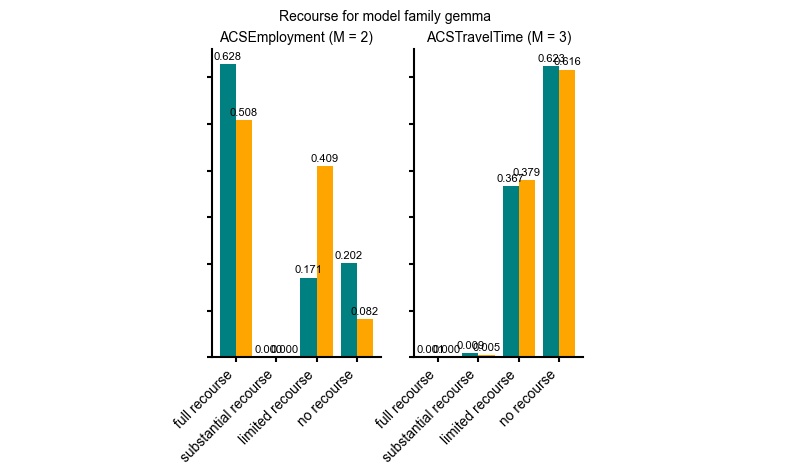

ACSIncome
Llama 3 70B, Meta Llama 3.1 70B, Meta Llama 3.1 70B (it), Llama 3 70B (it)

ACSEmployment
Meta Llama 3.2 1B (it), Meta Llama 3.2 3B (it), Llama 3 8B (it), Meta Llama 3.1 70B (it), Llama 3 70B (it)

ACSTravelTime
Meta Llama 3.2 3B (it), Llama 3.1 8B, Llama 3 8B (it), Meta Llama 3.1 70B (it), Llama 3 70B (it)

ACSPublicCoverage
Llama 3 8B (it), Llama 3.1 8B (it), Meta Llama 3.1 70B (it), Llama 3 70B (it)



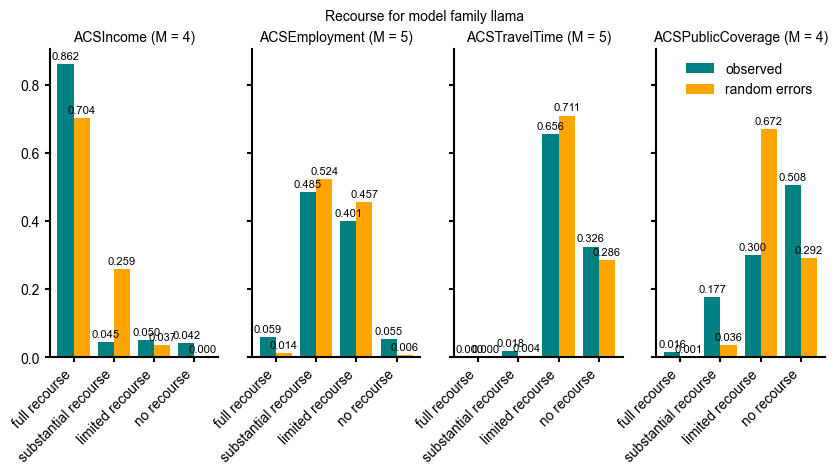

ACSIncome
Mistral 7B, Mistral 7B (it), Mixtral 8x7B, Mixtral 8x7B (it), Mixtral 8x22B, Mixtral 8x22B (it)

ACSEmployment
Mistral 7B (it), Mixtral 8x7B (it)

ACSTravelTime
Mistral 7B (it), Mixtral 8x22B (it)

ACSPublicCoverage
Mixtral 8x7B (it), Mixtral 8x22B (it)



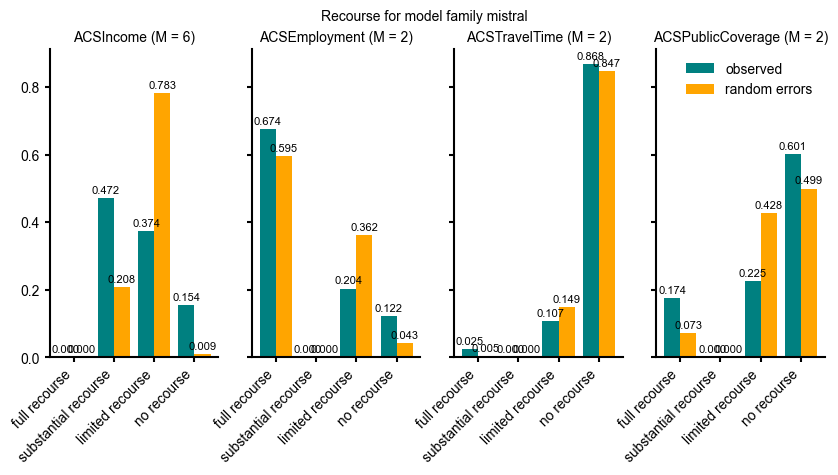

ACSIncome
OLMo 2 7B, OLMo 7B (it)

ACSEmployment
OLMo 2 7B (it)

ACSTravelTime


ACSPublicCoverage




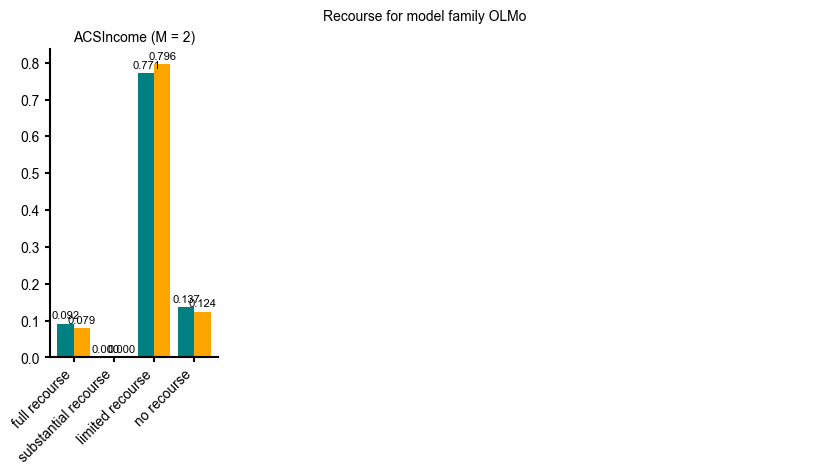

ACSIncome
Qwen 2 7B, Qwen 2 7B (it), Qwen 2 72B, Qwen 2 72B (it)

ACSEmployment
Qwen 2 7B, Qwen 2 7B (it), Qwen 2 72B

ACSTravelTime
Qwen 2 7B (it)

ACSPublicCoverage
Qwen 2 72B (it)



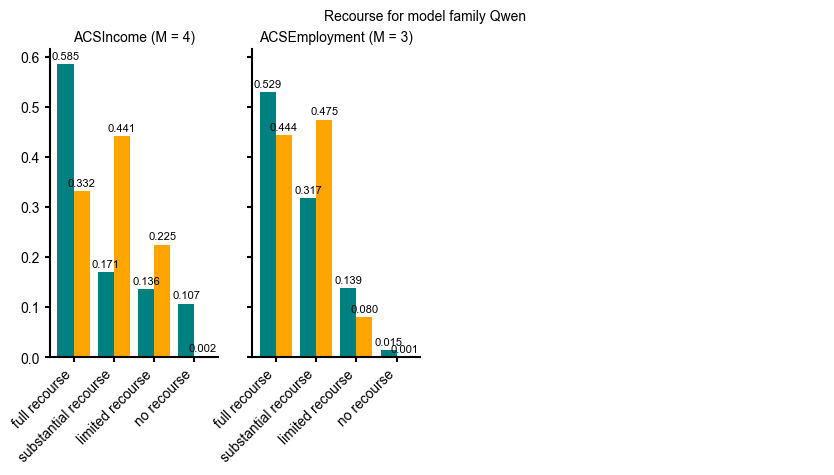

ACSIncome
Yi 34B (chat)

ACSEmployment
Yi 34B, Yi 34B (chat)

ACSTravelTime
Yi 34B

ACSPublicCoverage
Yi 34B, Yi 34B (chat)



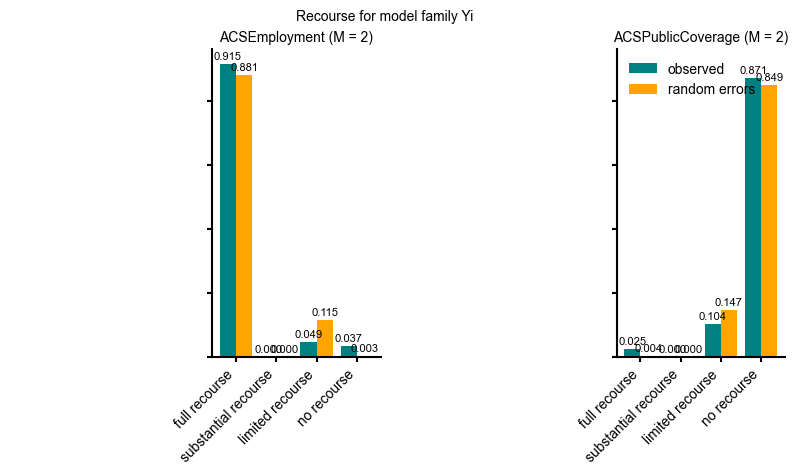

In [20]:
# Recourse for Model Family

for model_family in model_families:
    fig, axs = plt.subplots(1,len(tasks), figsize=(10,4), sharey=True)
    fig.suptitle(f'Recourse for model family {model_family}')


    for i, task in enumerate(tasks):
        # filter predictions 
        predictions_model_family = predictions_above_baseline[task].filter(like=model_family)
        models = list(predictions_model_family.columns)
        print(f"{task}\n{', '.join([prettify_model_name(key_to_model(k)) for k in models])}\n")

        M = len(models)
        if M > 1: 
            axs[i].set_title(f"{task} (M = {M})")

            # observed 
            values, counts = get_observed_rejections(predictions=predictions_model_family, restrict_only_pos_instances=True, true_labels=data[task][1])
            # pad counts with zeros to ensure correct slicing for recourse
            values_list = list(values)
            counts_padded = torch.tensor([counts[values_list.index(num)] if num in values_list else torch.tensor(0) for num in torch.arange(M+1)])
            num_samples = sum(counts)
                
            # expected
            #prob_random = np.array([sp.special.binom(num_models, i) * 2**(-num_models) for i in range(0,num_models+1)])
            fn_rates_filtered = [fn_rates[task][model] for model in models]
            prob_expected = np.array([poisson_binom_agreement(fn_rates=fn_rates_filtered, k=i) for i in range(0,M+1)])

            # recourse
            cut_off = (M+1)//2
            recourse = {'full': slice(1), 'substantial': slice(1,cut_off), 'limited': slice(cut_off, M), 'no': slice(M, M+1)}

            width=0.4
            axs[i].set_xticks(np.arange(4)+0.5*width, [f'full recourse',f'substantial recourse', f'limited recourse', f'no recourse'], rotation=45, ha='right')
            obs_bar = axs[i].bar(np.arange(4), [counts_padded[s].sum()/num_samples for _,s in recourse.items()], width=width, color='teal', label='observed')
            rnd_bar = axs[i].bar(np.arange(4)+width, [prob_expected[s].sum() for _,s in recourse.items()], width=width, color='orange', label='random errors')
            axs[i].bar_label(obs_bar, fmt='%.3f', label_type='edge', size=8, padding=2)
            axs[i].bar_label(rnd_bar, fmt='%.3f', label_type='edge', size=8, padding=2)

            if i==3:
                axs[i].legend()
        else: 
            axs[i].axis("off")

    plt.savefig(RESULTS_ROOT_DIR/f'figures/same_prompt_individual_recourse_family_{model_family}.png')
    plt.show()



### Recourse by top-k models

In [21]:
topk=10
sorted_models = sorted(accuracies[task].items(), key=lambda item: item[1], reverse=True)
sorted_models[:topk]

[('meta-llama--Meta-Llama-3-70B-Instruct', 0.7471206810215323),
 ('meta-llama--Meta-Llama-3.1-70B-Instruct', 0.7448892637201416),
 ('mistralai--Mixtral-8x7B-Instruct-v0.1', 0.7435451422748157),
 ('mistralai--Mixtral-8x22B-Instruct-v0.1', 0.7400925950329003),
 ('Qwen--Qwen2-72B-Instruct', 0.7329590877544386),
 ('01-ai--Yi-34B-Chat', 0.7225838758137206),
 ('mlfoundations--tabula-8b', 0.7220567693645732),
 ('meta-llama--Meta-Llama-3-8B-Instruct', 0.7068233929842132),
 ('meta-llama--Meta-Llama-3.1-8B-Instruct', 0.7053474949266004),
 ('01-ai--Yi-34B', 0.7027822435407497)]

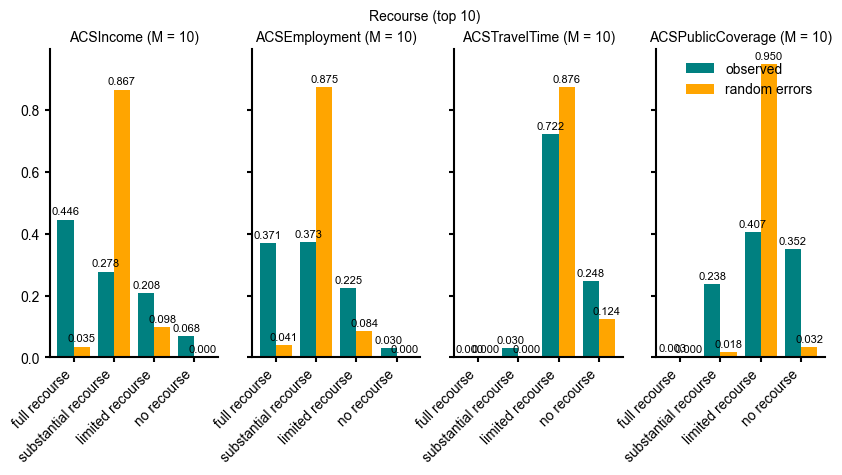

In [22]:
# Recourse top-k models
topk=10

fig, axs = plt.subplots(1,len(tasks), figsize=(10,4), sharey=True)
fig.suptitle(f'Recourse (top {topk})')

for i, task in enumerate(tasks):
    sorted_models = sorted(accuracies[task].items(), key=lambda item: item[1], reverse=True)
    models_topk = list(zip(*sorted_models[:topk]))[0]
    predictions_topk = predictions_above_baseline[task].filter(models_topk)
    M = topk
    axs[i].set_title(f"{task} (M = {M})")

    # observed 
    values, counts = get_observed_rejections(predictions=predictions_topk, restrict_only_pos_instances=True, true_labels=data[task][1])
    # pad counts with zeros to ensure correct slicing for recourse
    values_list = list(values)
    counts_padded = torch.tensor([counts[values_list.index(num)] if num in values_list else torch.tensor(0) for num in torch.arange(M+1)])
    num_samples = sum(counts)
        
    # expected
    #prob_random = np.array([sp.special.binom(num_models, i) * 2**(-num_models) for i in range(0,num_models+1)])
    fn_rates_filtered = [fn_rates[task][model] for model in models_topk]
    prob_expected = np.array([poisson_binom_agreement(fn_rates=fn_rates_filtered, k=i) for i in range(0,M+1)])

    # recourse
    cut_off = (M+1)//2
    recourse = {'full': slice(1), 'substantial': slice(1,cut_off), 'limited': slice(cut_off, M), 'no': slice(M, M+1)}

    width=0.4
    axs[i].set_xticks(np.arange(4)+0.5*width, [f'full recourse',f'substantial recourse', f'limited recourse', f'no recourse'], rotation=45, ha='right')
    obs_bar = axs[i].bar(np.arange(4), [counts_padded[s].sum()/num_samples for _,s in recourse.items()], width=width, color='teal', label='observed')
    rnd_bar = axs[i].bar(np.arange(4)+width, [prob_expected[s].sum() for _,s in recourse.items()], width=width, color='orange', label='random errors')
    axs[i].bar_label(obs_bar, fmt='%.3f', label_type='edge', size=8, padding=2)
    axs[i].bar_label(rnd_bar, fmt='%.3f', label_type='edge', size=8, padding=2)

    if i==len(tasks)-1:
        axs[i].legend()

plt.savefig(RESULTS_ROOT_DIR/f'figures/same_prompt_individual_recourse_top{topk}.png')
plt.show()



### Recourse including classical/baseline models

In [57]:
baselines.keys()

dict_keys(['Constant', 'LR', 'GBM', 'XGBoost'])

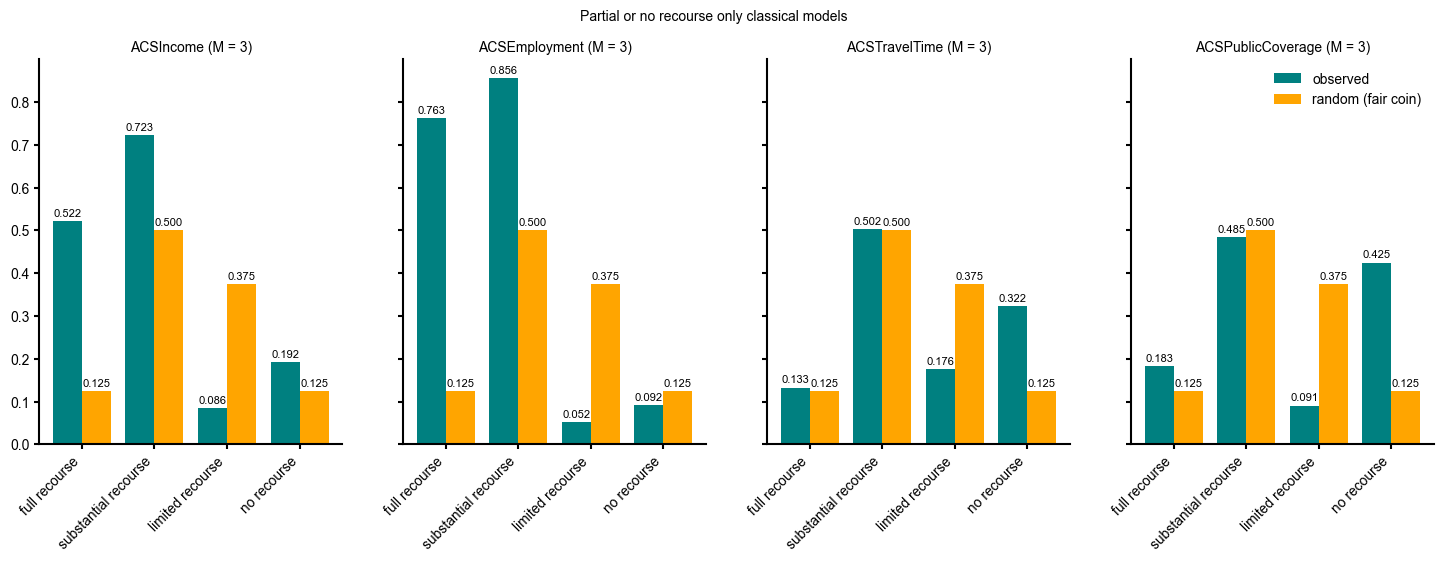

In [ ]:
fig, axs = plt.subplots(1,len(tasks), figsize=(18,5), sharey=True); fig.suptitle('Partial or no recourse only classical models')

for i, task in enumerate(tasks):
    num_models = 3
    axs[i].set_title(f"{task} (M = {num_models})")

    predictions_only_baselines = baseline_predictions[task].filter(items=[f'LR_task-{task}', f'GBM_task-{task}', f'XGBoost_task-{task}'])

    num_models_rejected = num_models - predictions_only_baselines.sum(axis=1) #series: count of rejecting models
    
    y_test = data[task][1]
    indices_pos = y_test[y_test==1].index
    num_models_rejected_neg = num_models_rejected.loc[indices_pos] #filter: only positive instances
        
    prob_random = np.array([sp.special.binom(num_models, i) * 2**(-num_models) for i in range(0,num_models+1)])
    counts_rejected = np.array([len(num_models_rejected[num_models_rejected==i]) for i in range(0,num_models+1)])
    counts_rejects_neg = np.array([len(num_models_rejected_neg[num_models_rejected_neg==i]) for i in range(0,num_models+1)])

    cut_off = (num_models+1)//2
    recourse = {'full' : counts_rejects_neg[0]/indices_pos.shape[0], # all models accept
                'partial' : counts_rejects_neg[:-1].sum()/indices_pos.shape[0], # some model accepts, but not all
                'substantial' : counts_rejects_neg[:cut_off].sum()/indices_pos.shape[0], # less than half rejects
                'limited' : counts_rejects_neg[cut_off:-1].sum()/indices_pos.shape[0], # at least half rejects, not all
                'no' : counts_rejects_neg[-1]/indices_pos.shape[0] # no model accepts
                }
    

    width=0.4
    axs[i].set_xticks(np.arange(4)+0.5*width, [f'full recourse',f'substantial recourse', f'limited recourse', f'no recourse'], rotation=45, ha='right')
    obs_bar = axs[i].bar(np.arange(4), [recourse['full'], recourse['substantial'], recourse['limited'], recourse['no']], width=width, color='teal', label='observed')
    rnd_bar = axs[i].bar(np.arange(4)+width, [prob_random[0], prob_random[:cut_off].sum(), prob_random[cut_off:-1].sum(), prob_random[-1]], width=width, color='orange', label='random (fair coin)')
    axs[i].bar_label(obs_bar, fmt='%.3f', label_type='edge', size=8, padding=2)
    axs[i].bar_label(rnd_bar, fmt='%.3f', label_type='edge', size=8, padding=2)

    if i==3:
        axs[i].legend()

plt.savefig(RESULTS_ROOT_DIR/'figures/same_prompt_individual_recourse_only_classical.png')
plt.show()

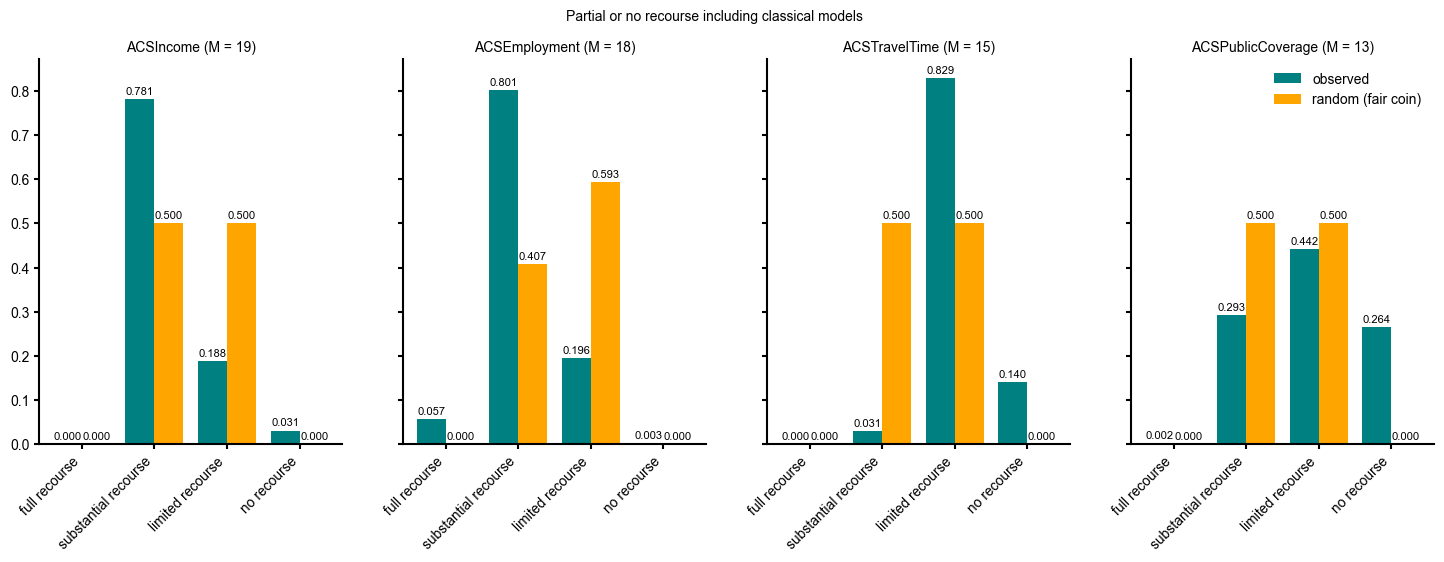

In [ ]:
fig, axs = plt.subplots(1,len(ACS_TASKS), figsize=(18,5), sharey=True); fig.suptitle('Partial or no recourse including classical models')

for i, task in enumerate(ACS_TASKS):
    num_models = len(models_above_baseline[task]) + 3
    axs[i].set_title(f"{task} (M = {num_models})")

    predictions_with_baselines = pd.concat([baseline_predictions[task].filter(items=[f'LR_task-{task}', f'GBM_task-{task}', f'XGBoost_task-{task}']), predictions_above_baseline[task]], axis=1) #todo: only if baseline is better than constant

    num_models_rejected = num_models - predictions_with_baselines.sum(axis=1) #series: count of rejecting models
    
    y_test = data[task][1]
    indices_pos = y_test[y_test==1].index
    num_models_rejected_neg = num_models_rejected.loc[indices_pos] #filter: only positive instances
        
    prob_random = np.array([sp.special.binom(num_models, i) * 2**(-num_models) for i in range(0,num_models+1)])
    counts_rejected = np.array([len(num_models_rejected[num_models_rejected==i]) for i in range(0,num_models+1)])
    counts_rejects_neg = np.array([len(num_models_rejected_neg[num_models_rejected_neg==i]) for i in range(0,num_models+1)])

    cut_off = (num_models+1)//2
    recourse = {'full' : counts_rejects_neg[0]/indices_pos.shape[0], # all models accept
                'partial' : counts_rejects_neg[:-1].sum()/indices_pos.shape[0], # some model accepts, but not all
                'substantial' : counts_rejects_neg[:cut_off].sum()/indices_pos.shape[0], # less than half rejects
                'limited' : counts_rejects_neg[cut_off:-1].sum()/indices_pos.shape[0], # at least half rejects, not all
                'no' : counts_rejects_neg[-1]/indices_pos.shape[0] # no model accepts
                }
    

    width=0.4
    axs[i].set_xticks(np.arange(4)+0.5*width, [f'full recourse',f'substantial recourse', f'limited recourse', f'no recourse'], rotation=45, ha='right')
    obs_bar = axs[i].bar(np.arange(4), [recourse['full'], recourse['substantial'], recourse['limited'], recourse['no']], width=width, color='teal', label='observed')
    rnd_bar = axs[i].bar(np.arange(4)+width, [prob_random[0], prob_random[:cut_off].sum(), prob_random[cut_off:-1].sum(), prob_random[-1]], width=width, color='orange', label='random (fair coin)')
    axs[i].bar_label(obs_bar, fmt='%.3f', label_type='edge', size=8, padding=2)
    axs[i].bar_label(rnd_bar, fmt='%.3f', label_type='edge', size=8, padding=2)

    if i==3:
        axs[i].legend()

plt.savefig(RESULTS_ROOT_DIR/'figures/same_prompt_individual_recourse_incl_classical.png')
plt.show()